# 🥞 Stacking Classifier (Стектеу)

> **Принципі ("Сарапшылар кеңесі"):** Бір-біріне ұқсамайтын бірнеше базалық модельдер (Base estimators) оқытылып, өз болжамдарын жасайды. Содан кейін осы болжамдар жаңа деректер ретінде қарастырылып, қорытынды шешімді шығаратын "Бас модельге" (Meta-learner) беріледі.

---

## ⚙️ Негізгі Параметрлер (sklearn.ensemble.StackingClassifier)

| Параметр | Түсіндірмесі | Кеңес |
| :--- | :--- | :--- |
| `estimators` | Базалық модельдердің тізімі (атауы мен моделі бар кортеждер/tuples). | Әртүрлі табиғаты бар модельдерді (KNN, SVM, Naive Bayes) таңдаңыз. |
| `final_estimator` | Қорытынды шешім шығаратын Meta-learner. | Әдетте қарапайым модель қойылады (мысалы, `LogisticRegression`). Егер `None` болса, автоматты түрде логистикалық регрессия қолданылады. |
| `cv` | Базалық модельдерді оқыту кезіндегі айқаспалы тексеру (Cross-Validation) бөліктерінің саны. | Әдепкі мәні — 5. Деректер аз болса, осы күйінде қалдырған жөн. |
| `passthrough` | Базалық модельдердің болжамдарымен бірге бастапқы деректерді де Meta-learner-ге беру (True/False). | Әдепкі мәні — `False`. Егер `True` болса, Meta-learner бастапқы белгілерді де көре алады, бірақ модель ауырлап кетуі мүмкін. |
| `n_jobs` | Параллельді есептеу үшін қолданылатын процессор ядроларының саны. | `-1` мәнін берсеңіз, процесті барынша тездетеді. |

---

## 💻 Жылдам Бастау (Quick Start)

```python
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Базалық модельдерді анықтау (әртүрлі алгоритмдер)
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('nb', GaussianNB())
]

# 2. Meta-learner-ді анықтау (Қорытынды жасаушы)
meta_model = LogisticRegression()

# 3. Stacking моделін жинау
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# 4. Модельді жаттықтыру
stacking_clf.fit(X_train, y_train)

# 5. Болжам жасау және тексеру
predictions = stacking_clf.predict(X_test)
print(f"Stacking Дәлдігі: {accuracy_score(y_test, predictions):.2f}")

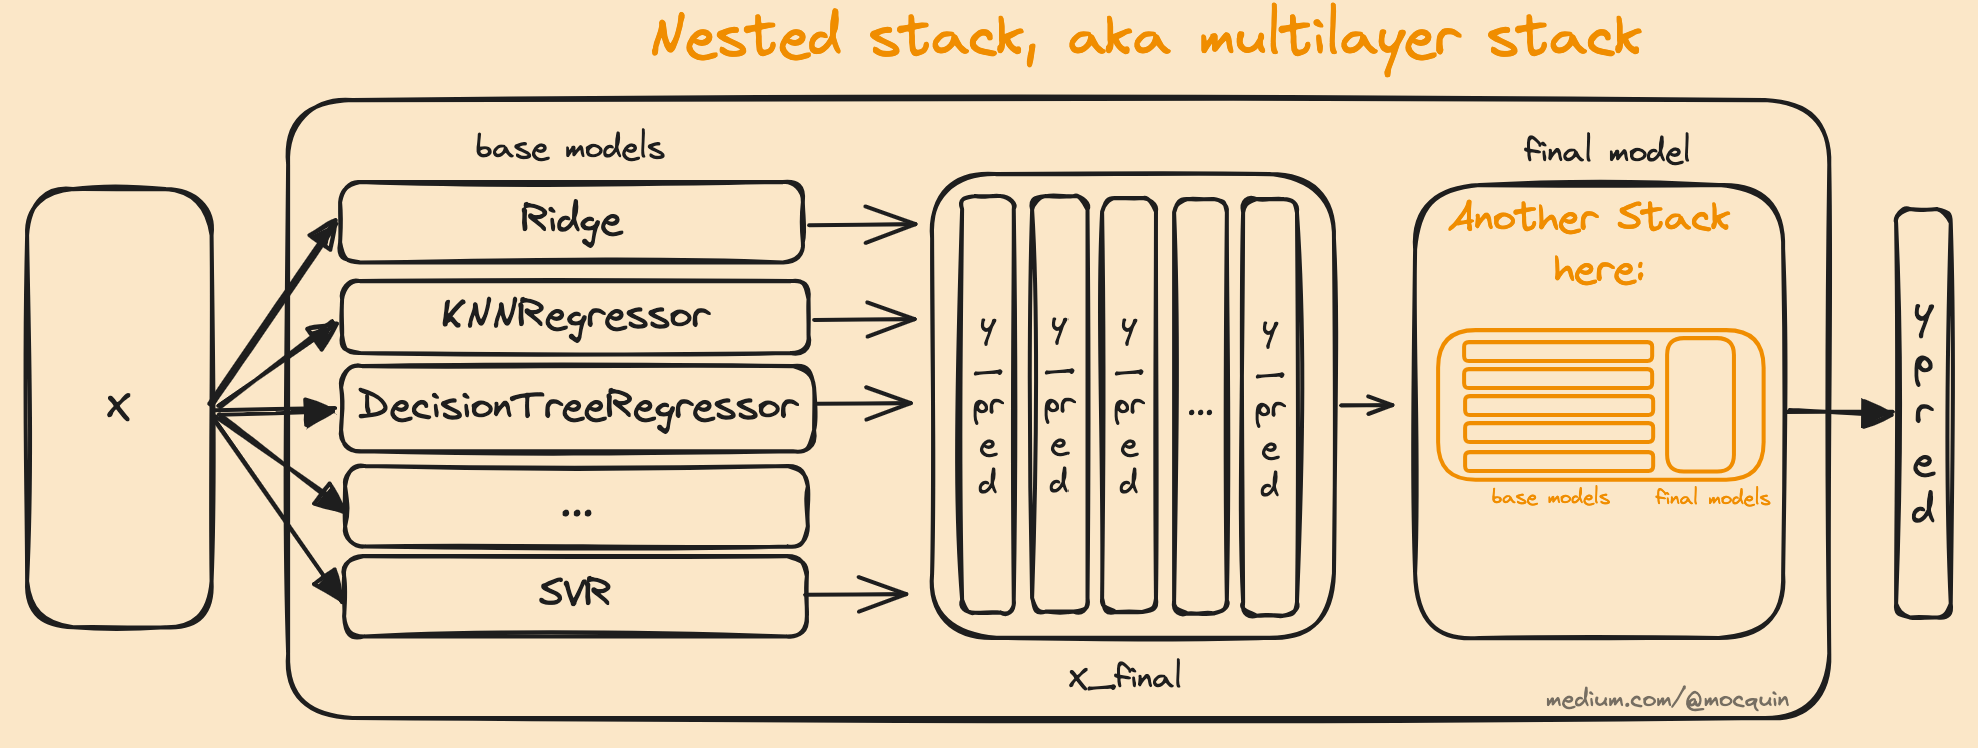

# 🥞 Stacking Ensemble - Титаник жобасы (Толық нұсқа)
Бұл жобада біз 3 түрлі базалық алгоритмді (KNN, SVM, Naive Bayes) жеке оқытып, содан кейін олардың басын қосатын **Stacking** моделін жаттықтырамыз. Мақсат — ансамбльдік әдістің дәлдікті қалай арттыратынын көзбен көру.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Визуализация стилін баптау
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Деректер жүктелуде...")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Қарапайым тазалау
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Белгілер мен нысана
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# Бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабтау (KNN және SVM үшін)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Деректер дайын! ✅")

Деректер жүктелуде...
Деректер дайын! ✅


In [2]:
print("Базалық модельдер оқытылуда...\n")

base_models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✔️ {name} дәлдігі: {acc * 100:.2f}%")

Базалық модельдер оқытылуда...

✔️ K-Nearest Neighbors дәлдігі: 78.77%
✔️ Support Vector Machine дәлдігі: 81.01%
✔️ Naive Bayes дәлдігі: 77.09%


In [3]:
print("Stacking (Ансамбль) моделі құрылуда...\n")

estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('nb', GaussianNB())
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_scaled, y_train)
stack_preds = stacking_clf.predict(X_test_scaled)
stack_acc = accuracy_score(y_test, stack_preds)
results['Stacking Ensemble'] = stack_acc

print(f"🚀 Stacking қорытынды дәлдігі: {stack_acc * 100:.2f}%\n")

print("-" * 50)
print(classification_report(y_test, stack_preds, target_names=['Қайтыс болды (0)', 'Аман қалды (1)']))
print("-" * 50)

Stacking (Ансамбль) моделі құрылуда...

🚀 Stacking қорытынды дәлдігі: 79.89%

--------------------------------------------------
                  precision    recall  f1-score   support

Қайтыс болды (0)       0.80      0.88      0.84       105
  Аман қалды (1)       0.80      0.69      0.74        74

        accuracy                           0.80       179
       macro avg       0.80      0.78      0.79       179
    weighted avg       0.80      0.80      0.80       179

--------------------------------------------------


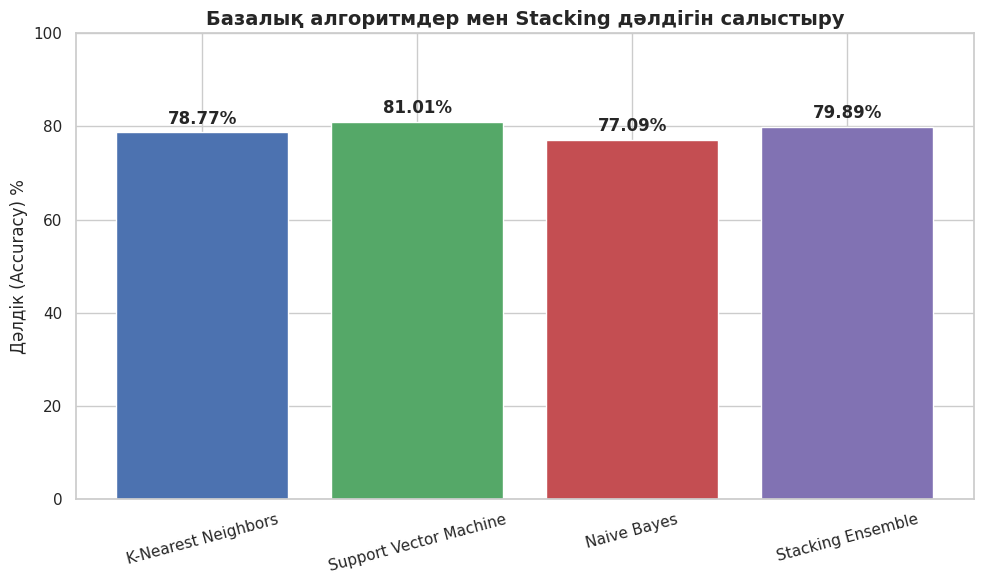

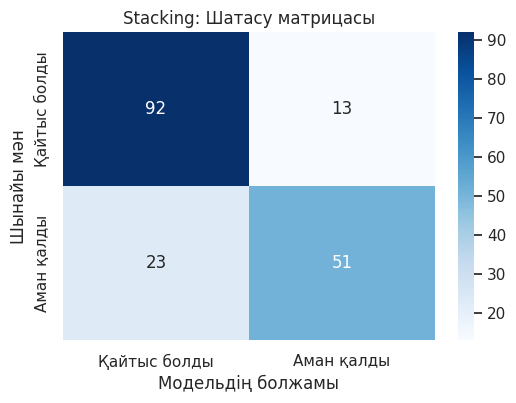

In [4]:
# 1. Дәлдіктерді салыстыру графигі
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']
bars = plt.bar(results.keys(), [a * 100 for a in results.values()], color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title("Базалық алгоритмдер мен Stacking дәлдігін салыстыру", fontsize=14, fontweight='bold')
plt.ylabel("Дәлдік (Accuracy) %", fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2. Шатасу матрицасы (Confusion Matrix)

cm = confusion_matrix(y_test, stack_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Қайтыс болды', 'Аман қалды'],
            yticklabels=['Қайтыс болды', 'Аман қалды'])
plt.title('Stacking: Шатасу матрицасы')
plt.ylabel('Шынайы мән')
plt.xlabel('Модельдің болжамы')
plt.show()